# LAB 2.2: TÍCH CHẬP, LỌC NHIỄU & PHÁT HIỆN BIÊN

**Mục tiêu:** Notebook này đánh dấu bước chuyển mình từ xử lý điểm ảnh độc lập sang xử lý lân cận (Neighborhood Processing). Bạn sẽ tự tay triển khai phép Tích chập (Convolution), phân biệt các bộ lọc làm trơn (Gaussian) với bộ lọc khôi phục (Median). Cuối cùng, bạn sẽ học cách máy tính tìm kiếm đường biên vật thể bằng Đạo hàm (Sobel, Canny) và ứng dụng chúng để tạo ra các tác phẩm nghệ thuật hoặc giải cứu ảnh hỏng.

## PHẦN 0: THIẾT LẬP MÔI TRƯỜNG (SETUP)

In [11]:
# 1. Import các thư viện cốt lõi
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Cấu hình kích thước ảnh hiển thị
plt.rcParams['figure.figsize'] = [15, 6]

# 2. Kết nối với Google Drive
from google.colab import drive
drive.mount('/content/drive')

path_dir = '/content/drive/MyDrive/ComputerVision-IT23M/ThucHanh_Chuong1/data/'

# 3. Hàm hiển thị ảnh hỗ trợ
def show_img(img, title="Image", cmap_type=None):
    plt.figure()
    if len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray' if cmap_type is None else cmap_type)
    plt.title(title)
    plt.axis('off')
    plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## PHẦN 1: BẢN CHẤT CỦA TÍCH CHẬP & CUSTOM KERNEL

Tích chập hoạt động dựa trên một "Cửa sổ trượt" (Sliding Window / Kernel) quét qua ảnh. Tại mỗi vị trí, nó nhân các giá trị trong Kernel với pixel bên dưới rồi cộng tổng lại. Thay vì dùng các bộ lọc có sẵn, ta sẽ tự định nghĩa một Kernel làm sắc nét ảnh (Sharpening Kernel).

Kernel làm nét có đặc điểm: Tập trung cường độ vào pixel trung tâm (trọng số dương lớn) và trừ bớt pixel xung quanh (trọng số âm) để làm gắt đường biên.


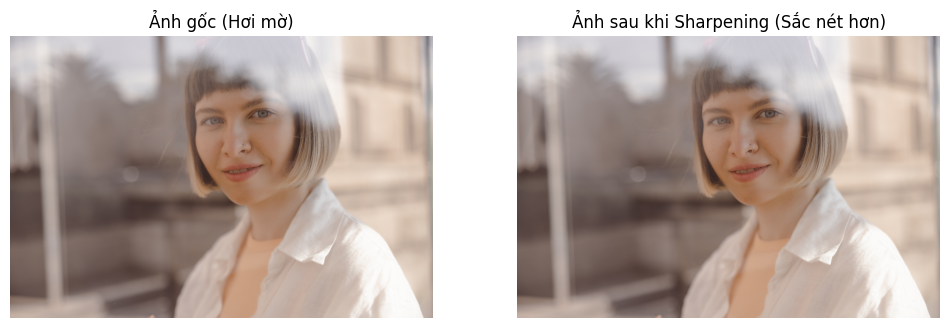

In [12]:
# Đọc ảnh (Ví dụ ảnh chân dung bị mờ nhẹ)
img_blur = cv2.imread(os.path.join(path_dir, 'blurry_portrait.jpg'))

if img_blur is not None:
    # 1. Khai báo Kernel Làm nét (Sharpening) dạng Numpy Array
    # Trọng số trung tâm là 5, xung quanh là -1
    kernel_sharp = np.array([[ 0, -1,  0],
                             [-1,  5, -1],
                             [ 0, -1,  0]])

    # 2. Áp dụng Tích chập bằng cv2.filter2D
    # ddepth = -1 nghĩa là ảnh đầu ra giữ nguyên độ sâu màu (như uint8) của ảnh đầu vào
    img_sharpened = cv2.filter2D(img_blur, -1, kernel_sharp)

    # 3. Trực quan hóa so sánh
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    axs[0].imshow(cv2.cvtColor(img_blur, cv2.COLOR_BGR2RGB))
    axs[0].set_title("Ảnh gốc (Hơi mờ)")
    axs[1].imshow(cv2.cvtColor(img_sharpened, cv2.COLOR_BGR2RGB))
    axs[1].set_title("Ảnh sau khi Sharpening (Sắc nét hơn)")
    for ax in axs: ax.axis('off')
    plt.show()

## PHẦN 1.5: XỬ LÝ VIỀN ẢNH KHI TÍCH CHẬP (PADDING / BORDER TYPES)

Khi "Cửa sổ trượt" (Kernel) di chuyển đến sát mép của bức ảnh, tâm của Kernel nằm ở pixel ngoài cùng, dẫn đến một nửa Kernel bị... rớt ra ngoài khoảng không!.

Để phép nhân ma trận vẫn diễn ra bình thường, máy tính bắt buộc phải "đắp" thêm một lớp viền ảo xung quanh bức ảnh (gọi là Padding). Cách chúng ta chọn đắp viền như thế nào sẽ ảnh hưởng đến chất lượng các pixel nằm ở rìa bức ảnh.

Các kiểu đắp viền phổ biến trong OpenCV:

* `BORDER_CONSTANT`: Đắp viền màu đen (Giá trị 0). Dễ gây ra vệt đen ở viền ảnh sau khi tích chập.
* `BORDER_REPLICATE`: Kéo dài pixel ngoài cùng ra.
* `BORDER_REFLECT`: Tạo hiệu ứng gương phản chiếu tại mép ảnh.

In [18]:
# Tạo một bức ảnh giả lập cực nhỏ (chỉ 5x5 pixel) để dễ quan sát sự thay đổi ở viền
small_img = np.array([[10, 10, 10, 10, 10],
                      [10, 50, 50, 50, 10],
                      [10, 50, 200, 50, 10],
                      [10, 50, 50, 50, 10],
                      [10, 10, 10, 10, 10]], dtype=np.uint8)

# Giả sử ta dùng Kernel kích thước 3x3, ta cần đắp viền 1 pixel ở mọi hướng (Trên, Dưới, Trái, Phải)
pad_size = 1

# 1. Đắp viền Hằng số (Đen = 0)
padded_constant = cv2.copyMakeBorder(small_img, pad_size, pad_size, pad_size, pad_size, cv2.BORDER_CONSTANT, value=0)

# 2. Đắp viền Lặp lại (Kéo dài pixel ở mép)
padded_replicate = cv2.copyMakeBorder(small_img, pad_size, pad_size, pad_size, pad_size, cv2.BORDER_REPLICATE)

# 3. Đắp viền Phản chiếu (Như chiếc gương ở mép)
padded_reflect = cv2.copyMakeBorder(small_img, pad_size, pad_size, pad_size, pad_size, cv2.BORDER_REFLECT)

# Hàm in ma trận đẹp mắt
def print_matrix(name, matrix):
    print(f"--- {name} ---")
    print(matrix)
    print()

print("--- ẢNH GỐC (5x5) ---")
print(small_img)
print("\nLưu ý các giá trị 10 nằm ở rìa ảnh gốc.\n")

print_matrix("BORDER_CONSTANT (Viền bị bọc bởi số 0)", padded_constant)
print_matrix("BORDER_REPLICATE (Viền lặp lại số 10)", padded_replicate)
print_matrix("BORDER_REFLECT (Viền phản chiếu số 50 ra ngoài)", padded_reflect)

# Mẹo thực chiến: Khi dùng cv2.filter2D hoặc cv2.GaussianBlur, OpenCV mặc định sử dụng BORDER_REFLECT để viền ảnh trông tự nhiên nhất!

--- ẢNH GỐC (5x5) ---
[[ 10  10  10  10  10]
 [ 10  50  50  50  10]
 [ 10  50 200  50  10]
 [ 10  50  50  50  10]
 [ 10  10  10  10  10]]

Lưu ý các giá trị 10 nằm ở rìa ảnh gốc.

--- BORDER_CONSTANT (Viền bị bọc bởi số 0) ---
[[  0   0   0   0   0   0   0]
 [  0  10  10  10  10  10   0]
 [  0  10  50  50  50  10   0]
 [  0  10  50 200  50  10   0]
 [  0  10  50  50  50  10   0]
 [  0  10  10  10  10  10   0]
 [  0   0   0   0   0   0   0]]

--- BORDER_REPLICATE (Viền lặp lại số 10) ---
[[ 10  10  10  10  10  10  10]
 [ 10  10  10  10  10  10  10]
 [ 10  10  50  50  50  10  10]
 [ 10  10  50 200  50  10  10]
 [ 10  10  50  50  50  10  10]
 [ 10  10  10  10  10  10  10]
 [ 10  10  10  10  10  10  10]]

--- BORDER_REFLECT (Viền phản chiếu số 50 ra ngoài) ---
[[ 10  10  10  10  10  10  10]
 [ 10  10  10  10  10  10  10]
 [ 10  10  50  50  50  10  10]
 [ 10  10  50 200  50  10  10]
 [ 10  10  50  50  50  10  10]
 [ 10  10  10  10  10  10  10]
 [ 10  10  10  10  10  10  10]]



## PHẦN 2: LỌC TRƠN (GAUSSIAN) VS LỌC KHÔI PHỤC (MEDIAN)

* **Lọc Gaussian:** Dùng hàm phân phối chuẩn 2D để giảm nhiễu êm dịu, bảo toàn chi tiết tốt hơn Lọc Trung bình (Mean) nhưng vẫn làm mờ ảnh. Không thể xử lý nhiễu muối tiêu.
* **Lọc Trung vị (Median Filter):** Là bộ lọc thống kê phi tuyến tính. Nó thu thập pixel lân cận, sắp xếp và lấy giá trị ở giữa. Đây là "khắc tinh" thực sự của nhiễu muối tiêu vì các điểm nhiễu (0 hoặc 255) bị đẩy về hai đầu danh sách và bị loại bỏ hoàn toàn.

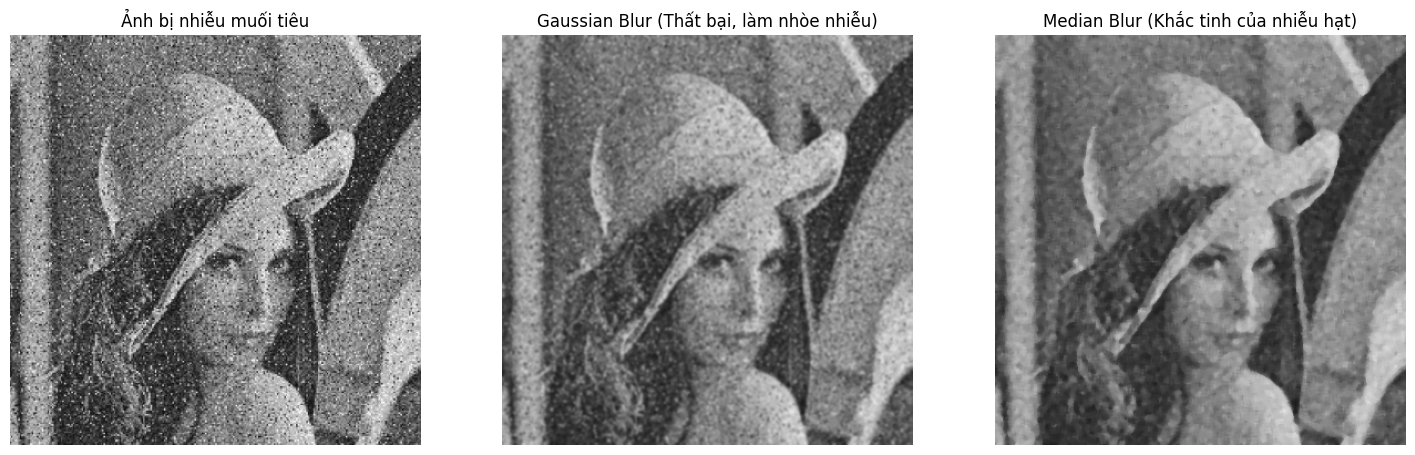

In [13]:
# Tải ảnh bị nhiễu muối tiêu (salt and pepper noise)
img_salt_pepper = cv2.imread(os.path.join(path_dir, 'salt_pepper_noise.jpg'))

if img_salt_pepper is not None:
    # 1. Thử dùng Gaussian Blur (Bộ lọc tuyến tính)
    gaussian_result = cv2.GaussianBlur(img_salt_pepper, (5, 5), 0)

    # 2. Dùng Lọc Trung vị - Median Blur (Bộ lọc thống kê)
    median_result = cv2.medianBlur(img_salt_pepper, 5)

    # So sánh
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    axs[0].imshow(cv2.cvtColor(img_salt_pepper, cv2.COLOR_BGR2RGB)); axs[0].set_title("Ảnh bị nhiễu muối tiêu")
    axs[1].imshow(cv2.cvtColor(gaussian_result, cv2.COLOR_BGR2RGB)); axs[1].set_title("Gaussian Blur (Thất bại, làm nhòe nhiễu)")
    axs[2].imshow(cv2.cvtColor(median_result, cv2.COLOR_BGR2RGB)); axs[2].set_title("Median Blur (Khắc tinh của nhiễu hạt)")
    for ax in axs: ax.axis('off')
    plt.show()

## PHẦN 2.5: BỘ LỌC THỐNG KÊ MIN/MAX & HÌNH THÁI HỌC (MORPHOLOGY)

Bên cạnh Lọc Trung vị (Median Filter), Lọc Min và Lọc Max là hai bộ lọc thống kê vô cùng quan trọng, tạo tiền đề cho môn **Hình thái học toán học** (Mathematical Morphology). Chúng thường được dùng trên ảnh nhị phân (trắng/đen).

* **Erosion (Co lại / Lọc Min):** Kernel quét qua ảnh, thay thế pixel trung tâm bằng giá trị **nhỏ nhất** trong lân cận. Tác dụng: "Ăn mòn" các vùng màu trắng, giúp dọn sạch các đốm nhiễu trắng li ti bên ngoài vật thể.
* **Dilation (Giãn nở / Lọc Max):** Kernel quét qua ảnh, thay thế pixel trung tâm bằng giá trị **lớn nhất** trong lân cận. Tác dụng: "Bơm phồng" các vùng màu trắng, giúp lấp đầy các lỗ hổng màu đen bên trong vật thể.


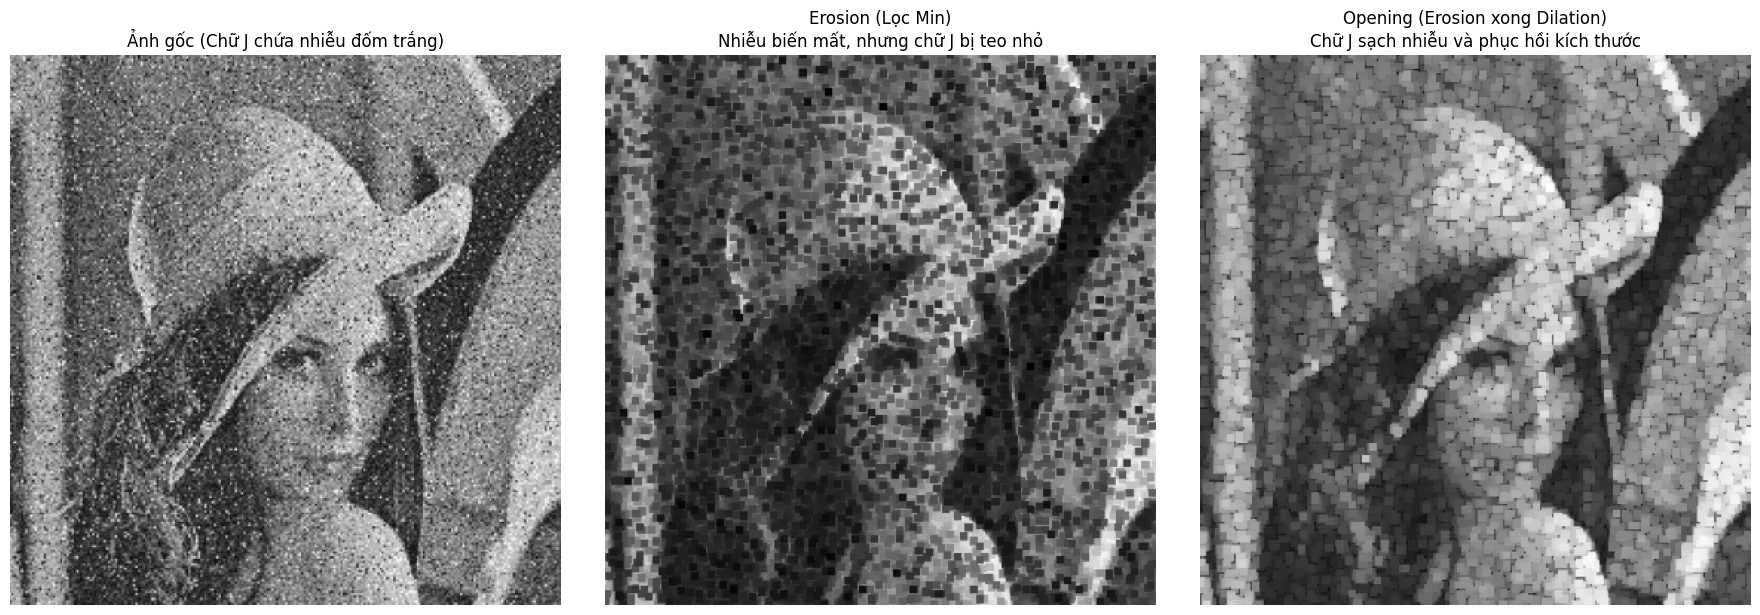

In [20]:
# Tải một bức ảnh nhị phân (Ví dụ: ảnh scan văn bản hoặc vân tay bị nhiễu lốm đốm)
img_j_noise = cv2.imread(os.path.join(path_dir, 'salt_pepper_noise.jpg'), cv2.IMREAD_GRAYSCALE)

if img_j_noise is not None:
    # 1. Định nghĩa Kernel cho Morphology (Ma trận toàn số 1)
    kernel_morph = np.ones((5, 5), np.uint8)

    # 2. Áp dụng Erosion (Co lại - Lọc Min) để khử các đốm nhiễu trắng bên ngoài
    img_erosion = cv2.erode(img_j_noise, kernel_morph, iterations=1)

    # 3. Áp dụng Dilation (Giãn nở - Lọc Max) để lấp đầy các lỗ hổng đen bên trong (giả sử dùng một ảnh khác bị lủng lỗ)
    # Ở đây ta áp dụng Dilation lên chính ảnh Erosion để phục hồi kích thước ban đầu của vật thể (gọi là phép Mở - Opening)
    img_opening = cv2.dilate(img_erosion, kernel_morph, iterations=1)

    # 4. Hiển thị so sánh
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    axs[0].imshow(img_j_noise, cmap='gray')
    axs[0].set_title("Ảnh gốc (Chữ J chứa nhiễu đốm trắng)")

    axs[1].imshow(img_erosion, cmap='gray')
    axs[1].set_title("Erosion (Lọc Min)\nNhiễu biến mất, nhưng chữ J bị teo nhỏ")

    axs[2].imshow(img_opening, cmap='gray')
    axs[2].set_title("Opening (Erosion xong Dilation)\nChữ J sạch nhiễu và phục hồi kích thước")

    for ax in axs: ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Vui lòng tải lên file ảnh nhị phân chứa nhiễu 'j_noisy.png'.")

## PHẦN 3: PHÁT HIỆN BIÊN BẰNG ĐẠO HÀM (SOBEL) & VẤN ĐỀ `CV_64F`

Đường biên là nơi cường độ sáng thay đổi đột ngột. Máy tính dùng Đạo hàm để tìm biên.
**⚠️ Lỗi kinh điển:** Khi tính đạo hàm, đi từ Sáng (255) sang Tối (0), đạo hàm sẽ mang **giá trị Âm**. Nếu lưu bằng `uint8` (`cv2.CV_8U`), các giá trị âm này bị ép về 0 khiến bạn mất một nửa số đường biên. Giải pháp là BẮT BUỘC phải dùng `cv2.CV_64F` (Float 64-bit) để lưu trữ tạm thời.

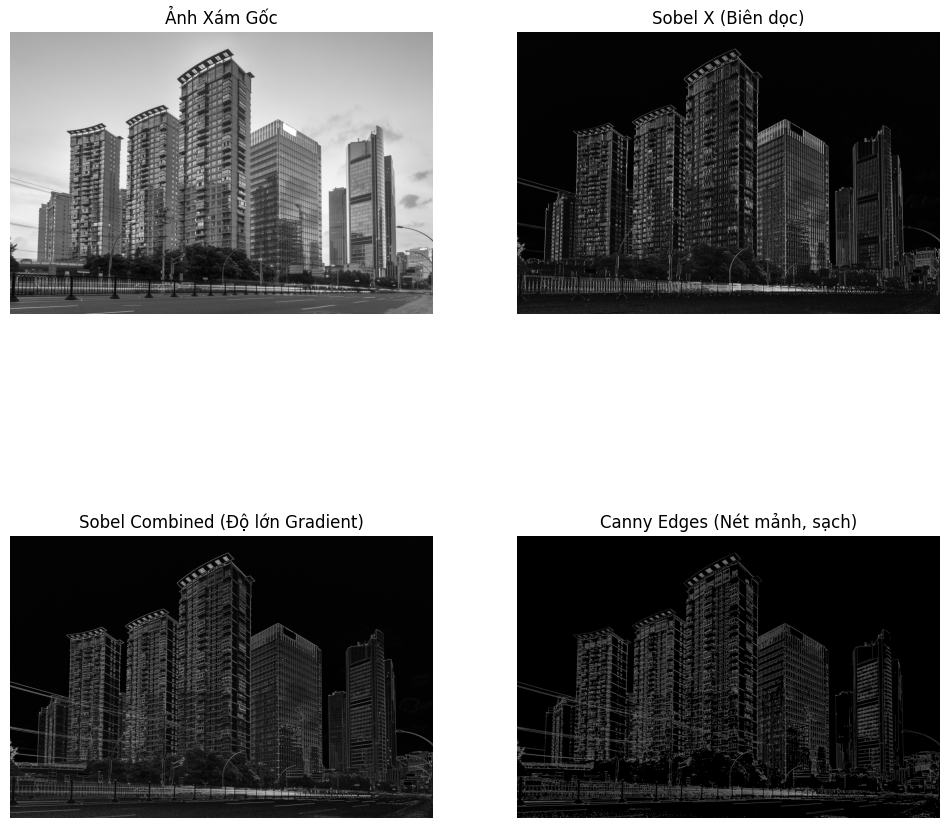

In [14]:
# Tải một ảnh phong cảnh hoặc công trình kiến trúc
img_building = cv2.imread(os.path.join(path_dir, 'building.jpg'), cv2.IMREAD_GRAYSCALE)

if img_building is not None:
    # 1. Tính Sobel X và Y với kiểu dữ liệu Float 64-bit
    sobel_x = cv2.Sobel(img_building, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_building, cv2.CV_64F, 0, 1, ksize=3)

    # 2. Lấy trị tuyệt đối và ép kiểu an toàn về uint8
    abs_grad_x = cv2.convertScaleAbs(sobel_x)
    abs_grad_y = cv2.convertScaleAbs(sobel_y)

    # 3. Gộp Độ lớn Gradient (Magnitude)
    sobel_combined = cv2.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)

    # 4. Thuật toán Canny (Pipeline tối ưu: Gaussian + Sobel + Non-max suppression + Thresholding)
    canny_edges = cv2.Canny(img_building, 100, 200)

    # Hiển thị
    fig, axs = plt.subplots(2, 2, figsize=(12, 12))
    axs[0,0].imshow(img_building, cmap='gray'); axs[0,0].set_title("Ảnh Xám Gốc")
    axs[0,1].imshow(abs_grad_x, cmap='gray'); axs[0,1].set_title("Sobel X (Biên dọc)")
    axs[1,0].imshow(sobel_combined, cmap='gray'); axs[1,0].set_title("Sobel Combined (Độ lớn Gradient)")
    axs[1,1].imshow(canny_edges, cmap='gray'); axs[1,1].set_title("Canny Edges (Nét mảnh, sạch)")
    for ax in axs.flat: ax.axis('off')
    plt.show()

## PHẦN 3.5: ĐẠO HÀM BẬC 2 - BỘ LỌC LAPLACIAN

Bộ lọc Sobel (Đạo hàm bậc 1) yêu cầu chúng ta phải dùng tới 2 Kernel riêng biệt (Sobel X và Sobel Y) rồi mới gộp lại để tìm biên hoàn chỉnh.

**Bộ lọc Laplacian (Đạo hàm bậc 2)** mang lại một ưu điểm lớn: Nó là bộ lọc **đẳng hướng** (isotropic), nghĩa là chỉ cần dùng đúng 1 Kernel duy nhất quét qua ảnh là có thể phát hiện được đường biên ở mọi hướng!

Tuy nhiên, đạo hàm bậc 2 lại có một "gót chân Achilles": Nó khuếch đại nhiễu lên cực kỳ mạnh. Do đó, **nguyên tắc sống còn** khi dùng Laplacian là bắt buộc phải làm mờ ảnh (Gaussian Blur) trước khi tìm biên.


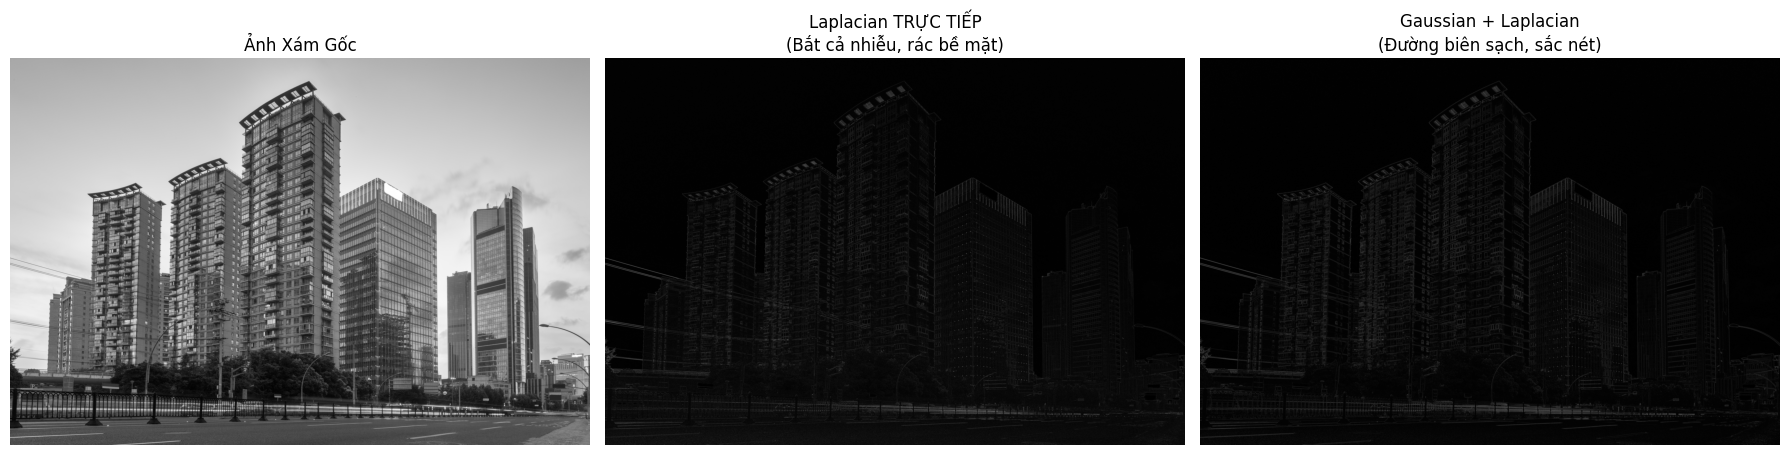

In [19]:
# Tải một bức ảnh có nhiều chi tiết hoặc vân bề mặt
img_laplace = cv2.imread(os.path.join(path_dir, 'building.jpg'), cv2.IMREAD_GRAYSCALE)

if img_laplace is not None:
    # --- TRƯỜNG HỢP 1: KHÔNG LÀM MỜ TRƯỚC (Sai lầm phổ biến) ---
    # Dùng cv2.CV_64F để giữ giá trị âm của đạo hàm giống hệt Sobel
    laplacian_noisy = cv2.Laplacian(img_laplace, cv2.CV_64F)
    laplacian_noisy = cv2.convertScaleAbs(laplacian_noisy)

    # --- TRƯỜNG HỢP 2: LÀM MỜ GAUSSIAN TRƯỚC KHI LAPLACIAN (Chuẩn mực) ---
    # Bước 1: Khử nhiễu bề mặt
    img_blurred = cv2.GaussianBlur(img_laplace, (5, 5), 0)
    # Bước 2: Tìm biên bằng Laplacian
    laplacian_clean = cv2.Laplacian(img_blurred, cv2.CV_64F)
    laplacian_clean = cv2.convertScaleAbs(laplacian_clean)

    # Hiển thị so sánh
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    axs[0].imshow(img_laplace, cmap='gray')
    axs[0].set_title("Ảnh Xám Gốc")

    axs[1].imshow(laplacian_noisy, cmap='gray')
    axs[1].set_title("Laplacian TRỰC TIẾP\n(Bắt cả nhiễu, rác bề mặt)")

    axs[2].imshow(laplacian_clean, cmap='gray')
    axs[2].set_title("Gaussian + Laplacian\n(Đường biên sạch, sắc nét)")

    for ax in axs: ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Vui lòng tải lên file ảnh 'building.jpg' để chạy thử nghiệm.")

## PHẦN 3.6: HIỂU SÂU CANNY QUA TƯƠNG TÁC THỜI GIAN THỰC

Thuật toán Canny sử dụng kỹ thuật **Phân ngưỡng kép (Hysteresis Thresholding)** với 2 giá trị: `MinVal` và `MaxVal`.

* **Pixel > MaxVal:** Chắc chắn là đường biên (Sure-edge).
* **Pixel < MinVal:** Chắc chắn không phải biên, bị loại bỏ ngay lập tức.
* **MinVal < Pixel < MaxVal:** Chỉ được công nhận là đường biên NẾU nó dính liền với một pixel "chắc chắn là biên" (Sure-edge).

Hãy dùng thanh trượt để tự tay điều chỉnh 2 thông số này. Bạn sẽ thấy: Nếu để `MaxVal` quá cao, ta chỉ bắt được các nét chính; Nếu hạ `MinVal` xuống thấp, các nét vẽ sẽ được nối liền lại với nhau nhưng đồng thời rác/nhiễu cũng bắt đầu xuất hiện.

In [21]:
from ipywidgets import interact, IntSlider

# Tải lại bức ảnh tòa nhà hoặc một ảnh có nhiều đường nét phức tạp
img_interactive_canny = cv2.imread(os.path.join(path_dir, 'building.jpg'), cv2.IMREAD_GRAYSCALE)

if img_interactive_canny is not None:
    # Bắt buộc phải làm mờ Gaussian trước khi dùng Canny để giảm nhiễu
    img_canny_blurred = cv2.GaussianBlur(img_interactive_canny, (5, 5), 0)

    def update_canny(min_val, max_val):
        # Đảm bảo min_val luôn nhỏ hơn max_val để thuật toán chạy đúng logic
        if min_val >= max_val:
            print("Cảnh báo: MinVal phải nhỏ hơn MaxVal!")
            return

        # Áp dụng thuật toán Canny với 2 ngưỡng tương tác
        edges = cv2.Canny(img_canny_blurred, min_val, max_val)

        plt.figure(figsize=(10, 8))
        plt.imshow(edges, cmap='gray')
        plt.title(f"Canny Edges - MinVal: {min_val} | MaxVal: {max_val}")
        plt.axis('off')
        plt.show()

    print("KÉO THANH TRƯỢT ĐỂ TÌM NGƯỠNG CANNY TỐI ƯU NHẤT:")
    interact(update_canny,
             min_val=IntSlider(value=100, min=0, max=255, step=5, description='Min Val:'),
             max_val=IntSlider(value=200, min=0, max=255, step=5, description='Max Val:'))
else:
    print("Vui lòng tải lên file ảnh 'building.jpg' để chạy thử nghiệm.")

KÉO THANH TRƯỢT ĐỂ TÌM NGƯỠNG CANNY TỐI ƯU NHẤT:


interactive(children=(IntSlider(value=100, description='Min Val:', max=255, step=5), IntSlider(value=200, desc…

## PHẦN 4: NGHỆ THUẬT PHÁT HIỆN BIÊN - PENCIL SKETCH (BÀI TẬP 2)

Bộ lọc Sobel tạo ra kết quả nền đen, viền trắng. Để tạo hiệu ứng tranh vẽ chì (Pencil Sketch) có nền giấy trắng, nét chì đen, ta chỉ cần kết hợp Sobel với phép toán đảo màu (Invert) cực kỳ đơn giản.

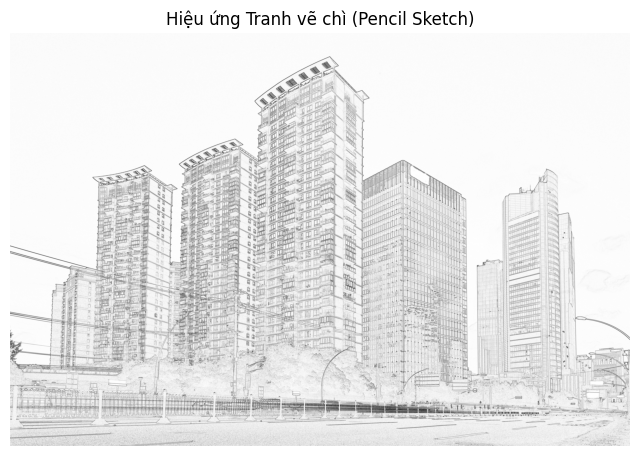

In [15]:
if img_building is not None:
    # Đảo ngược giá trị pixel (Mới = 255 - Cũ)
    pencil_sketch = 255 - sobel_combined
    # Hoặc cách khác: pencil_sketch = cv2.bitwise_not(sobel_combined)

    plt.figure(figsize=(8, 8))
    plt.imshow(pencil_sketch, cmap='gray')
    plt.title("Hiệu ứng Tranh vẽ chì (Pencil Sketch)")
    plt.axis('off')
    plt.show()

## PHẦN 5: THỬ THÁCH KHÔI PHỤC ẢNH - DENOISE CHALLENGE (BÀI TẬP 3)

**Luật chơi:** Bạn phải tự suy nghĩ xem nên áp dụng bộ lọc nào trước, bộ lọc nào sau cho một bức ảnh bị nhiễu hỗn hợp (nhòe mờ + hạt nhiễu). Đi sai thứ tự, bức ảnh sẽ càng tệ hơn.

**Pipeline Tiêu chuẩn:**

1. Khử hạt bằng Median Blur (Dọn rác trước tiên).
2. Làm mịn bằng Gaussian Blur (Làm đẹp bề mặt rạn nứt).
3. Lấy lại nét bằng Sharpening Kernel (Gọt giũa lại đường biên).

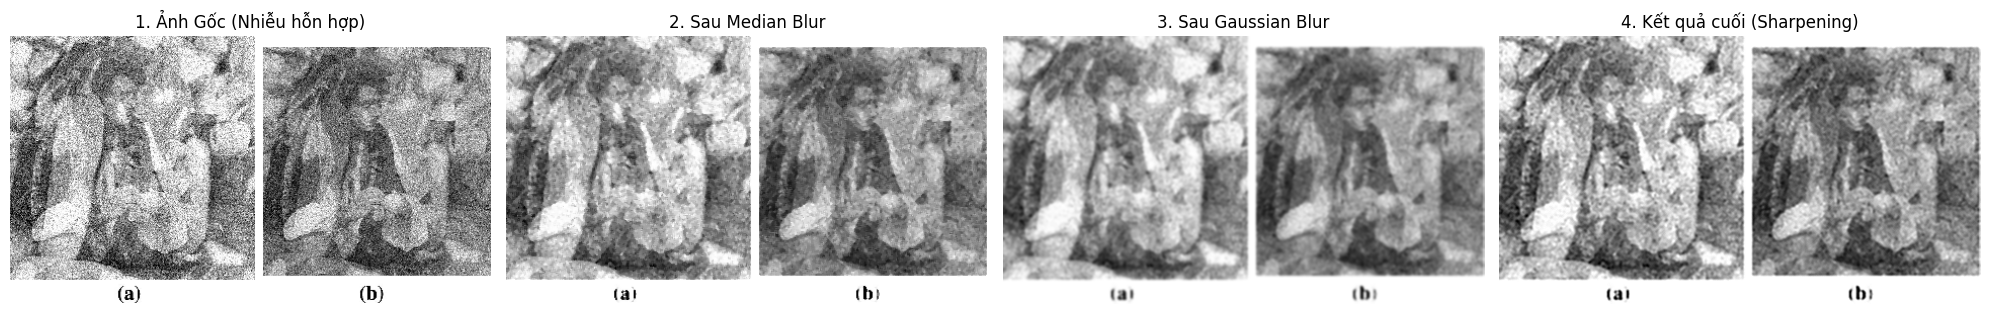

In [17]:
# Tải ảnh nhiễu hỗn hợp (thảm họa)
img_disaster = cv2.imread(os.path.join(path_dir, 'Noisy-mixed-images.png')) #'mixed_noise_disaster.jpg'))

if img_disaster is not None:
    # BƯỚC 1: Dọn rác (Khử hạt nhiễu muối tiêu)
    step1_median = cv2.medianBlur(img_disaster, 3)

    # BƯỚC 2: Làm mịn (Làm phẳng các vùng màu rạn nứt)
    step2_gaussian = cv2.GaussianBlur(step1_median, (5, 5), 0)

    # BƯỚC 3: Lấy lại nét (Dùng kernel_sharp đã định nghĩa ở Phần 1)
    final_restored = cv2.filter2D(step2_gaussian, -1, kernel_sharp)

    # Trực quan hóa Pipeline
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    axs[0].imshow(cv2.cvtColor(img_disaster, cv2.COLOR_BGR2RGB)); axs[0].set_title("1. Ảnh Gốc (Nhiễu hỗn hợp)")
    axs[1].imshow(cv2.cvtColor(step1_median, cv2.COLOR_BGR2RGB)); axs[1].set_title("2. Sau Median Blur")
    axs[2].imshow(cv2.cvtColor(step2_gaussian, cv2.COLOR_BGR2RGB)); axs[2].set_title("3. Sau Gaussian Blur")
    axs[3].imshow(cv2.cvtColor(final_restored, cv2.COLOR_BGR2RGB)); axs[3].set_title("4. Kết quả cuối (Sharpening)")
    for ax in axs: ax.axis('off')
    plt.tight_layout()
    plt.show()

## PHẦN 6: MINI-PROJECT TỔNG HỢP - DOCUMENT SCANNER (DỰ ÁN QUÉT TÀI LIỆU)

Bạn có bao giờ thắc mắc các ứng dụng như CamScanner trên điện thoại hoạt động như thế nào không? Bước đầu tiên và quan trọng nhất của chúng chính là tìm ra 4 cạnh của tờ giấy nằm trên mặt bàn.

Để làm được điều này, hệ thống sẽ chạy một "đường ống" (Pipeline) kết hợp sức mạnh của tất cả các công cụ bạn đã học trong chương này:

1. **Chuyển sang ảnh Xám (Grayscale):** Bỏ qua thông tin màu sắc không cần thiết để tăng tốc độ xử lý.
2. **Làm mờ (Gaussian Blur):** Khử các nhiễu nhỏ, vân gỗ trên mặt bàn hoặc nếp nhăn trên tờ giấy để chúng không bị nhận diện nhầm thành đường biên.
3. **Phát hiện biên (Canny Edge Detection):** Tách dứt khoát hình dáng tờ giấy ra khỏi nền.

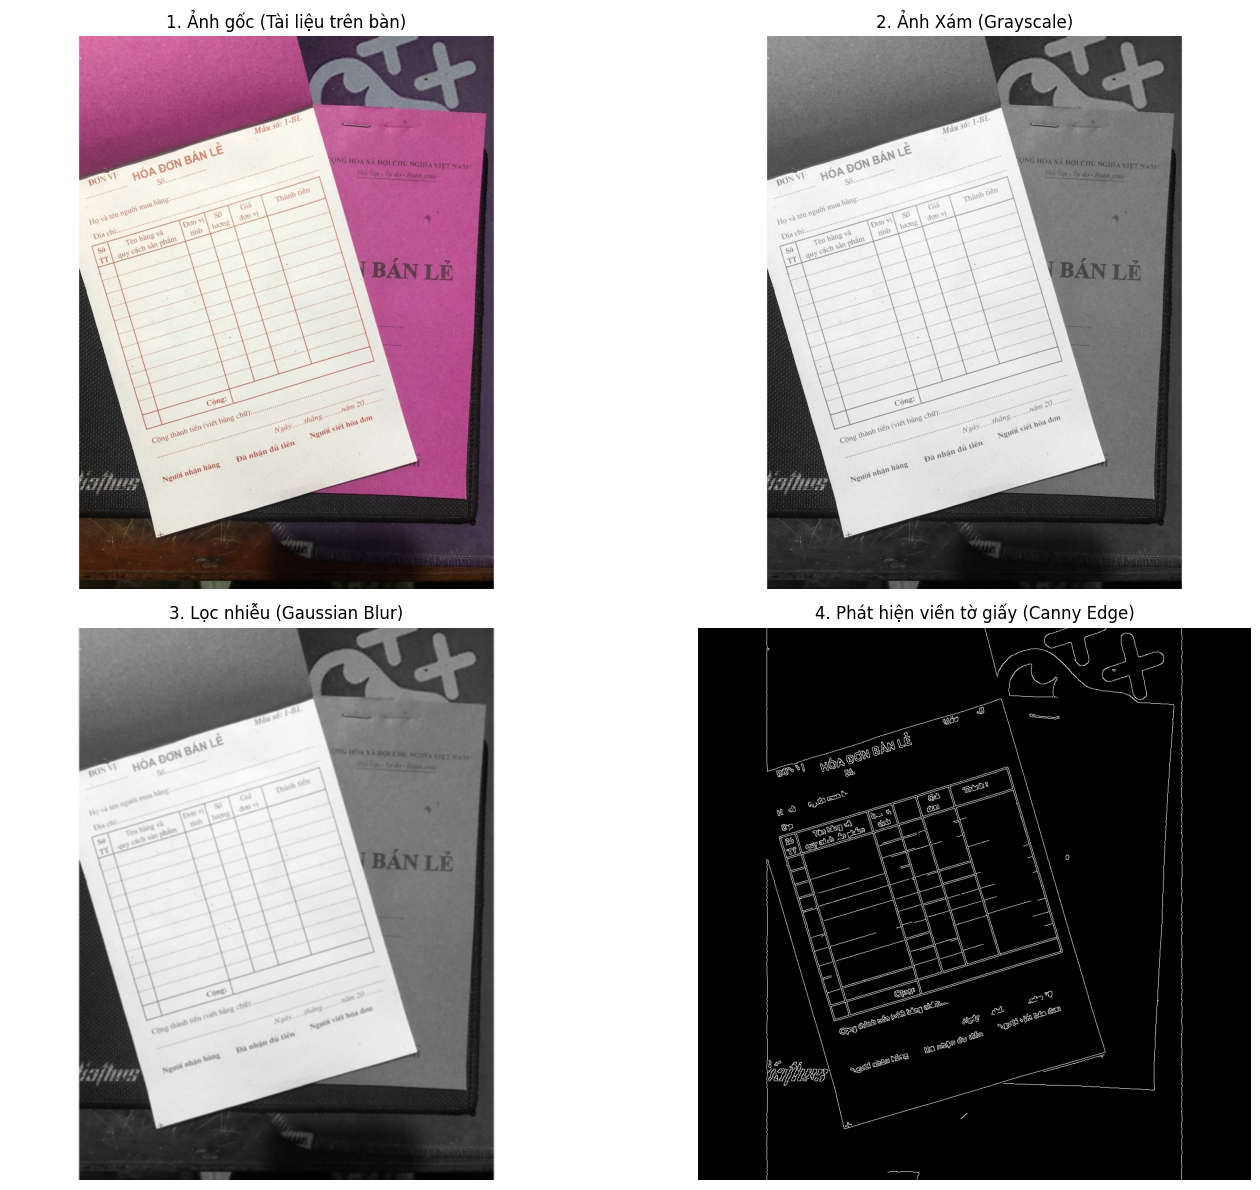

>> THÀNH CÔNG! Nếu chỉ còn lại một khung viền hình chữ nhật bao quanh tờ giấy, bạn đã sẵn sàng cho Chương 3 (Biến đổi phối cảnh để lật phẳng tờ giấy lại)!


In [22]:
# Tải một bức ảnh chụp một tờ giấy/hóa đơn/tài liệu đặt trên mặt bàn
img_document = cv2.imread(os.path.join(path_dir, 'receipt_on_table.jpg'))

if img_document is not None:
    # BƯỚC 1: Chuyển đổi sang ảnh xám
    gray_doc = cv2.cvtColor(img_document, cv2.COLOR_BGR2GRAY)

    # BƯỚC 2: Làm mịn bề mặt bằng Gaussian Blur
    # Kích thước Kernel (5,5) là đủ tốt để làm mờ vân gỗ mặt bàn
    blurred_doc = cv2.GaussianBlur(gray_doc, (5, 5), 0)

    # BƯỚC 3: Dùng Canny để bắt viền tờ giấy
    # Mẹo: Cần tinh chỉnh MinVal và MaxVal sao cho nó bắt được viền giấy mà bỏ qua chữ trên giấy
    edged_doc = cv2.Canny(blurred_doc, 75, 200)

    # Trực quan hóa từng bước trong Pipeline
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))

    # Ảnh màu gốc
    axs[0, 0].imshow(cv2.cvtColor(img_document, cv2.COLOR_BGR2RGB))
    axs[0, 0].set_title("1. Ảnh gốc (Tài liệu trên bàn)")

    # Ảnh Xám
    axs[0, 1].imshow(gray_doc, cmap='gray')
    axs[0, 1].set_title("2. Ảnh Xám (Grayscale)")

    # Ảnh sau khi làm mờ
    axs[1, 0].imshow(blurred_doc, cmap='gray')
    axs[1, 0].set_title("3. Lọc nhiễu (Gaussian Blur)")

    # Kết quả phát hiện biên
    axs[1, 1].imshow(edged_doc, cmap='gray')
    axs[1, 1].set_title("4. Phát hiện viền tờ giấy (Canny Edge)")

    for ax in axs.flat:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    print(">> THÀNH CÔNG! Nếu chỉ còn lại một khung viền hình chữ nhật bao quanh tờ giấy, bạn đã sẵn sàng cho Chương 3 (Biến đổi phối cảnh để lật phẳng tờ giấy lại)!")
else:
    print("Vui lòng tải lên file ảnh 'receipt_on_table.jpg' để chạy thử dự án này.")

## PHẦN 5: HỆ THỐNG BÀI TẬP TỰ LUYỆN (HOMEWORK)

Dưới đây là 10 bài tập để các bạn vận dụng sức mạnh của Tích chập (Convolution), Lọc nhiễu và Phát hiện biên. Hãy tạo các Code Cell mới ngay bên dưới để thực hiện.

**Bài 1: Tự tạo bộ lọc Lọc Trung Bình (Mean Filter) bằng NumPy**

* **Yêu cầu:** Thay vì dùng hàm `cv2.blur()`, hãy tự tạo một Kernel kích thước 5x5 dành cho Lọc trung bình và áp dụng nó lên ảnh bằng hàm `cv2.filter2D()`.
* **Hướng dẫn:** Kernel của lọc trung bình là một ma trận toàn số 1, sau đó chia cho tổng số phần tử. Dùng `kernel = np.ones((5, 5), np.float32) / 25`.

**Bài 2: Dịch chuyển ảnh bằng Tích chập (Translation Kernel)**

* **Yêu cầu:** Tích chập không chỉ để làm mờ hay làm nét. Hãy tạo một Kernel kích thước 3x3 sao cho khi quét qua ảnh, toàn bộ bức ảnh bị dịch chuyển sang phải 10 pixel và dịch xuống dưới 10 pixel.
* **Hướng dẫn:** Đây là phép biến đổi hình học dùng tích chập. Bạn cần tạo một ma trận dịch chuyển (Translation Matrix) 2x3 và dùng hàm `cv2.warpAffine()` để thấy sự khác biệt so với `filter2D`.

**Bài 3: Minh chứng "lỗi mất biên" khi dùng `uint8` cho Sobel**

* **Yêu cầu:** Tải một bức ảnh xám. Tính `cv2.Sobel()` theo hướng X bằng hai cách: Cách 1 dùng `cv2.CV_8U`, Cách 2 dùng `cv2.CV_64F` (sau đó lấy trị tuyệt đối). Hiển thị 2 ảnh cạnh nhau để chứng minh Cách 1 làm mất một nửa số đường biên.
* **Hướng dẫn:** Đường biên đi từ sáng sang tối sẽ cho đạo hàm âm. Nếu lưu bằng `CV_8U`, các giá trị âm bị ép về 0 (màu đen) nên đường biên đó biến mất hoàn toàn.

**Bài 4: Kỹ thuật Làm nét Unsharp Masking (Chuyên nghiệp)**

* **Yêu cầu:** Trong Photoshop có một công cụ rất nổi tiếng là "Unsharp Mask". Bản chất toán học của nó là: Lấy ảnh gốc trừ đi ảnh đã làm mờ (để lấy ra các chi tiết cạnh), sau đó cộng các chi tiết này ngược lại vào ảnh gốc. Hãy lập trình quy trình này.
* **Hướng dẫn:** Công thức: `Details = Original - GaussianBlur(Original)`. Sau đó `Sharpened = Original + alpha * Details` (với `alpha` là cường độ làm nét, ví dụ 1.5).

**Bài 5: Bắt viền vật thể bằng Hình thái học (Morphological Gradient)**

* **Yêu cầu:** Thay vì dùng Sobel hay Canny, hãy tìm đường biên của một bức ảnh nhị phân (ví dụ: ảnh bóng đen của một người) chỉ bằng 2 phép toán Lọc Min (Erosion) và Lọc Max (Dilation) đã học.
* **Hướng dẫn:** Đường biên chính là sự chênh lệch giữa ảnh sau khi Giãn nở và ảnh sau khi Co lại. Code: `Gradient = cv2.dilate(img, kernel) - cv2.erode(img, kernel)`. Hoặc dùng trực tiếp `cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)`.

**Bài 6: Phân tích Hướng của Đường biên (Gradient Direction)**

* **Yêu cầu:** Bộ lọc Sobel không chỉ cho biết "độ lớn" của đường biên (Magnitude) mà còn cho biết "hướng" của nó (Angle). Hãy tính và hiển thị ma trận Hướng của đường biên từ Sobel X và Sobel Y.
* **Hướng dẫn:** Dùng hàm `cv2.phase(sobel_x, sobel_y, angleInDegrees=True)` hoặc `np.arctan2(sobel_y, sobel_x)`.

**Bài 7: Tự động hóa thuật toán Canny (Auto-Canny)**

* **Yêu cầu:** Thuật toán Canny luôn đòi hỏi chúng ta phải tự đoán 2 ngưỡng `MinVal` và `MaxVal`. Hãy viết một hàm Python tự động tính ra 2 ngưỡng này dựa trên giá trị trung vị (median) của bức ảnh.
* **Hướng dẫn:** Tính `v = np.median(img)`. Đặt ngưỡng dưới `lower = int(max(0, (1.0 - 0.33) * v))` và ngưỡng trên `upper = int(min(255, (1.0 + 0.33) * v))`. Truyền `lower` và `upper` vào Canny.

**Bài 8: Khắc phục điểm chết của Laplacian**

* **Yêu cầu:** Lấy một bức ảnh bị nhiễu muối tiêu (Salt & Pepper). Áp dụng trực tiếp bộ lọc Laplacian và quan sát sự "tàn phá". Sau đó, hãy thiết kế một Pipeline để Laplacian có thể tìm được biên sạch sẽ trên bức ảnh này.
* **Hướng dẫn:** Nếu chỉ dùng Gaussian Blur trước Laplacian thì chưa đủ vì Gaussian không trị được nhiễu muối tiêu. Pipeline chuẩn: `Median Blur -> Gaussian Blur -> Laplacian`.

**Bài 9: Pipeline định vị Biển số xe (Mini-Project 2)**

* **Yêu cầu:** Tải một bức ảnh chụp đuôi xe ô tô. Hãy dùng các kỹ thuật đã học để làm nổi bật duy nhất hình dáng chữ nhật của biển số xe, làm chìm các chi tiết khác.
* **Hướng dẫn:** Chuyển ảnh Xám $\to$ Lọc Gaussian $\to$ Sobel X (vì biển số có nhiều đường sọc dọc của các chữ số) $\to$ Áp dụng Morphological Close (Dilation rồi Erosion) với kernel hình chữ nhật để nối các vạch chữ lại thành một khối đặc.

**Bài 10: So sánh độ phức tạp thời gian thuật toán (Time Profiling)**

* **Yêu cầu:** Phát hiện biên bằng Canny tốn nhiều bước xử lý ngầm (Gaussian, Sobel, Non-max suppression, Hysteresis). Hãy dùng thư viện `time` để đo xem Canny chạy chậm hơn bao nhiêu lần so với việc chỉ chạy bộ lọc Sobel (gộp X và Y) trên cùng một bức ảnh độ phân giải cao (ví dụ 4K).
* **Hướng dẫn:** Đọc ảnh lớn. `start = time.time()` trước khi gọi hàm và `end = time.time()` sau khi gọi. In ra độ chênh lệch thời gian. Bài tập này giúp sinh viên hiểu rõ sự đánh đổi giữa "Chất lượng" và "Tốc độ" (Trade-off) trong Computer Vision thực tế.